# Estimating Zodiacal light with ROSALIA 

## What is this? 

The purpose of this notebook is to demonstrate the use of ROSALIA to estimate Zodiacal light background. First we will generate a custom ROSALIA exposure object, and then use the `rosalia.core.exposure.zodiacal()` method to estimate the expected Zodiacal light background in our image. The code will generate a series of summary plots (png images) and a background image stored as a FITS format. 

The tutorial is divided on three examples: 

    - Estimating Zodiacal light using the STScI Zodiacal light model: 
    
    https://roman-docs.stsci.edu/roman-instruments/the-wide-field-instrument/observing-with-the-wfi/assessing-background-levels-for-wfi-observations#AssessingBackgroundLevelsforWFIObservations-Overview
    
    - Estimating Zodiacal light using the IRSA Zodiacal light model: https://irsa.ipac.caltech.edu/applications/BackgroundModel/
    
    - Estimating Zodiacal light using the COSMOGLOBE/Zodipy Zodiacal light model: https://cosmoglobe.github.io/zodipy/

## How to start

To run this notebook, please activate the "rosalia" kernel at the top right of your window.

## Imports

- *rosalia* for Roman/WFI stray-light analysis
- *astropy.time* to determine the start of the observation. 
- *asdf* for accessing the ASDF Roman mock observations
- *s3fs* for accessing the S3 cloud files in the Nexus
- *os* for Python path processing 

In [1]:
# This notebook demonstrates how to use ROSALIA to measure the expected zodiacal background in a simple image. 
import rosalia as rs
from astropy.time import Time
from astropy.coordinates import SkyCoord

In [2]:
# Define the target
target = 'alpha Centauri'
tgt = SkyCoord.from_name(target)
ra =  219.92041  # Right ascension, in degrees. 
dec = -60.835148 # Declination, in degrees.
PA = 30 # Position angle, in degrees.
date = Time("2027-01-01T00:00:00") # Date of the observation, in Astropy Time YYYY-MM-DDTHH:MM:SS format.
bandpass = "F129"
exptime = 600 # Exposure time, in seconds.

observer={"TELESCOP": "Roman/WFI", 
          "pointing": [ra, dec], 
          "FILTER":bandpass, 
          "PA_Y": PA, 
          "EXPSTART": date.mjd, 
          "EXPTIME": exptime}

prefix = "Pleiades"
custom_roman_exposure = rs.core.exposure(observer=observer, prefix=prefix) 


> Synthetic Roman_wfi_exposure
Horizons Error: No ephemeris for target "Roman Space Telescope (spacecraft)" after A.D. 2026-OCT-12 13:01:09.1824 TD
Using Lagrange point L2 as a fallback for the observer position.


Once the exposure object has been generated, just use the .zodiacal method to generate the different backgrounds. The results will be stored in _zody.fits images in the same directory as the input (or locally, if using the observer input). 

##### 1 - Estimating Zodiacal light using the STScI Zodiacal light model

Computing Zodiacal light...


100%|██████████| 18/18 [01:17<00:00,  4.31s/it]


1.4207009
1.4435946


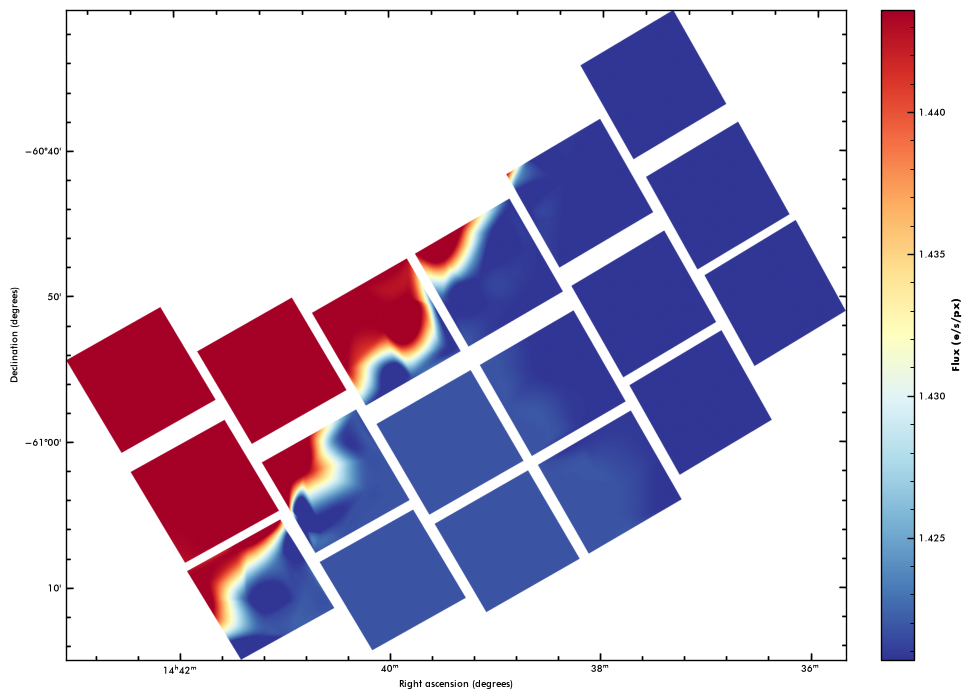

DEMO WARNING: make_stray_plot is Assuming F129.
21.285002495707324
21.302358954108183


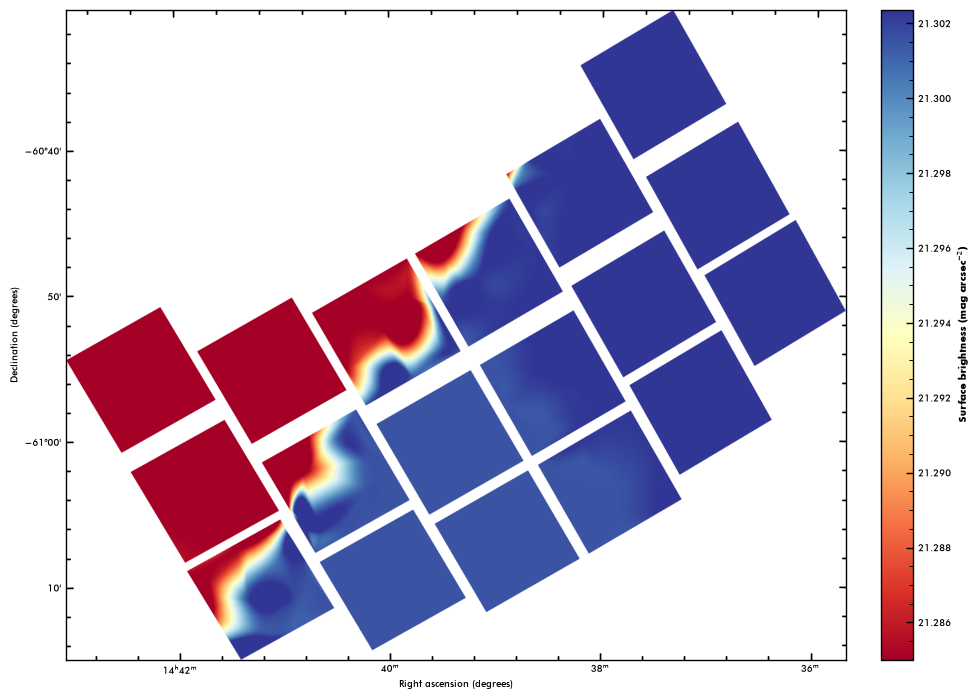

Output saved in: /Users/aborlaff/NASA/ROSALIA/notebooks/tutorials/Pleiades_Roman_RA_219.920_DEC_-60.835_MJD_61406.00000_PA_030.00_zody.fits


In [3]:
zodi_out = custom_roman_exposure.zodiacal(zody_mode="stsci")

##### 2 - Estimating Zodiacal light using the COSMOGLOBE/Zodipy Zodiacal light model (fastest)

In [ ]:
zodipy_zodi_out = custom_roman_exposure.zodiacal(zody_mode="zodipy")

Computing Zodiacal light...


100%|██████████| 18/18 [00:54<00:00,  3.02s/it]


##### 3 - Estimating Zodiacal light using the IRSA/IPAC Zodiacal light model (slowest)

In [ ]:
irsa_zodi_out = custom_roman_exposure.zodiacal(zody_mode="irsa")

## About this Notebook

**Author:** Alejandro S. Borlaff - NASA Ames Research Center (Code S) - a.s.borlaff@nasa.gov 

**Updated on** September 18, 2026. 